In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
def load_data(filepath):
  x_vals=[]
  y_vals=[]

  with open(filepath,"r") as f:
    lines=f.readlines()
    for line in lines[1:]:
      parts=line.split(",")
      x=float(parts[0])
      y=float(parts[1])
      x_vals.append(x)
      y_vals.append(y)
    return x_vals,y_vals

In [16]:
def gradient_descent(x_vals,y_vals,learning_rate=1e-7,iteration=20000):
  m=0
  b=0
  n=len(x_vals)
  for i in range(iteration):
      y_pred = [m * x_vals[i] + b for i in range(n)]
      dm = (-2.0 / n) * sum(x_vals[i] * (y_vals[i] - y_pred[i]) for i in range(n))
      db = (-2.0 / n) * sum((y_vals[i] - y_pred[i]) for i in range(n))

      m -= learning_rate * dm
      b -= learning_rate * db

  return m, b

In [10]:
def predict(x,m,b):
  return m*x+b

In [6]:
def plot_best_fit(x_vals,y_vals,m,b):
  plt.scatter(x_vals, y_vals, label="Data points")
  x_min, x_max = min(x_vals), max(x_vals)
  x_line = [x_min, x_max]
  y_line = [predict(x_min, m, b), predict(x_max, m, b)]
  plt.plot(x_line, y_line, label="Best fit line")
  plt.xlabel("Square Footage")
  plt.ylabel("Price")
  plt.title("Gradient Descent: Line of Best Fit")
  plt.grid(True)
  plt.legend()
  plt.show()


GD slope m = 171.86937139108915
GD intercept b = 0.554645398353095
Predicted price for 2500 sq ft (GD): 429673.98


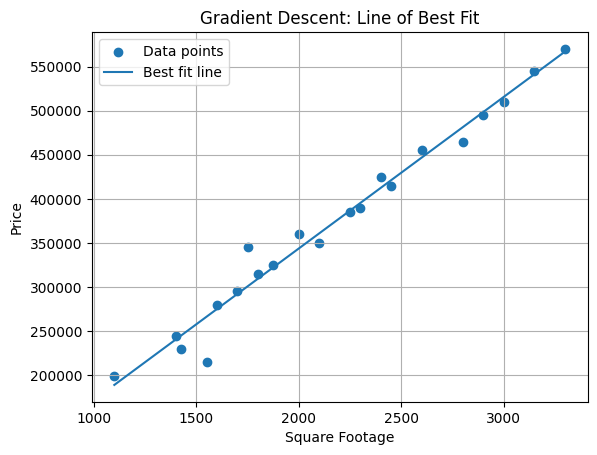

In [17]:
filepath = "/content/housing_prices - housing_prices.csv"
x_vals, y_vals = load_data(filepath)

m, b = gradient_descent(x_vals, y_vals)
print(f"GD slope m = {m}")
print(f"GD intercept b = {b}")
sqft = 2500
predicted_price = predict(sqft, m, b)
print(f"Predicted price for {sqft} sq ft (GD): {predicted_price:.2f}")

plot_best_fit(x_vals, y_vals, m, b)